# **Análisis de sentimientos mediante LSTM**

En el presente notebook se entrena una red neuronal recurrente (RNN), específicamente una **Long Short-Term Memory** (**LSTM**), para realizar una tarea de **análisis de sentimientos**.

Para ello, se utiliza el dataset ***IMDB Dataset of 50K Movie Reviews***, el cual contiene reseñas de películas clasificadas en dos categorías: positivas (1) y negativas (0).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def load_imdb_data(path_file):
    texts = []
    labels = []

    df = pd.read_csv(path_file)
    df = df.rename(columns={"0": "Comentario", "1": "Etiqueta"})

    texts = df["Comentario"]
    labels = df["Etiqueta"]

    return texts, labels

## **Dataset**

Se trabaja con **texto plano**, con el objetivo de comprender el proceso completo de preparación de datos necesario para su uso con modelos basados en *word embeddings*, como Word2Vec.

El dataset debe descargarse de [Kaggle](https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fmantri7%2Fimdb-movie-reviews-dataset%3Fresource%3Ddownload%23) y organizarse de la siguiente manera:

```
IMDB/
 ├── train/
 │    └── train_data.csv
 └── test/
      └── test_data.csv
```

Cada archivo contiene dos columnas:
* **Texto**: reseña de la película
* **Etiqueta**: 0 (negativo) o 1 (positivo)

Los datos se cargan con `pandas` y se separan en:
* X: textos
* y: etiquetas

In [ ]:
path = "/home/emiranda/Docuxmentos/UNIR/Datasets/IMDb/"

X_train_, y_train_ = load_imdb_data(path+"train/train_data.csv")
X_test, y_test = load_imdb_data(path+"test/test_data.csv")

### División de los datos

Dado que el dataset ya incluye conjuntos de entrenamiento y prueba (25,000 registros cada uno), **no es recomendable utilizar el conjunto de prueba como validación**.

Se genera un conjunto de validación a partir del conjunto de entrenamiento, con los siguientes porcentajes:
* Train: 80%
* Valid: 20%

Esto evita **data leakage** y permite una evaluación más confiable del modelo.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X_train_, y_train_,
                                                                stratify=y_train_,
                                                                test_size=0.2,
                                                                random_state=42)

### **Análisis inicial de datos**

Antes del entrenamiento, es necesario verificar:

**Balance de clases**:

Se debe comprobar que ambas clases estén razonablemente equilibradas. En caso contrario, pueden aplicarse técnicas como:

* Submuestreo (undersampling)
* Sobremuestreo (oversampling)
* Uso de métricas robustas (F1-score)

Text(0, 0.5, 'Valores')

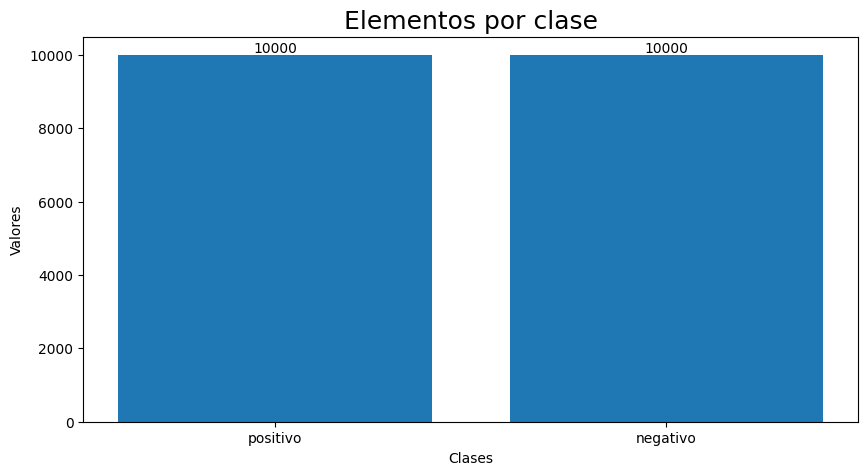

In [ ]:
import numpy as np
clases, valor  = np.unique(y_train, return_counts=True)

# Etiquetas del dataset
labels = ['positivo', 'negativo']

w = 10
h = 5
plt.figure(figsize=(w,h))

plt.xticks(range(len(labels)))
bars = plt.bar(labels, valor)
for bar in bars:
    # Altura de la barra
    yval = bar.get_height()
    # Texto en la parte superior
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.title("Elementos por clase", fontsize=18)
plt.xlabel('Clases')
plt.ylabel('Valores')

## Preprocesamiento de texto

El preprocesamiento incluye:
* Conversión a minúsculas
* Eliminación de signos de puntuación, números y caracteres irrelevantes
* (Opcional pero recomendable):
  * Eliminación de stopwords
  * Normalización (lemmatization o stemming)

In [ ]:
import re

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-záéíóúñ ]', '', text)
    return text.split()

## Tokenización

La tokenización consiste en dividir cada texto en unidades mínimas (tokens), generalmente palabras.

Ejemplo:

``
"Me encantó la película" → ["me", "encantó", "la", "película"]
``

Este paso es necesario antes de aplicar Word2Vec.

In [ ]:
X_train_tokens = [preprocess(t) for t in X_train]
X_valid_tokens = [preprocess(t) for t in X_valid]
X_test_tokens = [preprocess(t) for t in X_test]

## **Word2Vec**

Word2Vec es un algoritmo que genera **representaciones vectoriales densas (embeddings)** de palabras, capturando relaciones semánticas entre ellas.

**Consideraciones importantes**:

* Se entrena únicamente con el **conjunto de entrenamiento** (para evitar *data leakage*)
* La calidad de los embeddings depende del tamaño y diversidad del corpus

**Parámetros principales**
* ``sentences``: corpus tokenizado
* ``vector_size``: dimensión del embedding
* ``window``: tamaño de la ventana de contexto
* ``min_count``: frecuencia mínima de palabras
* ``workers``: número de procesos paralelos
* ``sg``: tipo de arquitectura
  * 0: CBOW
  * 1: Skip-gram

In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2
)

## Representación de los textos

El flujo actual usado en este notebook

``
Texto → Tokens → Word2Vec → Secuencia de vectores
``

Es decir:
* Cada palabra se reemplaza por su vector
* Cada texto se convierte en una secuencia de vectores

In [ ]:
def to_vectors(tokens, model, size):
    return [model.wv[word] for word in tokens if word in model.wv]

X_train_vec = [to_vectors(s, w2v_model, 100) for s in X_train_tokens]
X_valid_vec = [to_vectors(s, w2v_model, 100) for s in X_valid_tokens]
X_test_vec = [to_vectors(s, w2v_model, 100) for s in X_test_tokens]

## Padding de secuencias

Las LSTM requieren entradas de tamaño uniforme.

Por ello, las secuencias se ajustan a una longitud fija mediante **padding**:

* Secuencias cortas → se rellenan con ceros
* Secuencias largas → se recortan

Esto permite procesar datos en **batches**.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

max_len = 200  # recomendado limitar

X_train_pad = pad_sequences(
    [np.array(x) for x in X_train_vec],
    maxlen=max_len,
    padding='post',
    dtype='float32'
)

X_valid_pad = pad_sequences(
    [np.array(x) for x in X_valid_vec],
    maxlen=max_len,
    padding='post',
    dtype='float32'
)

X_test_pad = pad_sequences(
    [np.array(x) for x in X_test_vec],
    maxlen=max_len,
    padding='post',
    dtype='float32'
)

I0000 00:00:1777507316.131344   46470 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777507317.459705   46470 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Red LSTM

Una LSTM es un tipo de RNN diseñada para capturar dependencias a largo plazo mediante el uso de compuertas internas.

**Capa Masking**

Se utiliza para indicar al modelo qué valores corresponden al padding:

``
Masking(mask_value=0.0, input_shape=(max_len, embedding_dim))
``

Permite ignorar los ceros agregados durante el padding

⚠️ Importante:
* No todas las configuraciones o capas soportan masking correctamente
* Alternativa: usar mask_zero=True en una capa Embedding (en el otro enfoque)

--

**Parámetros de la capa LSTM**
* ``units``: número de neuronas
* ``return_sequences``:
    * False: salida final (clasificación)
    * True: salida en cada paso temporal (secuencias)
* ``return_state``:
    * False: solo salida
    * True: salida + estados internos

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Masking

model = Sequential([
    Masking(mask_value=0.0, input_shape=(max_len, 100)),
    LSTM(128),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

## Regularización

Para reducir el sobreajuste se pueden emplear:
* Dropout
* Early stopping
* Regularización L2

In [ ]:
import tensorflow as tf

my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, min_delta=1e-2),
    tf.keras.callbacks.ModelCheckpoint(filepath='best_model.keras', save_best_only = True)
]

In [ ]:
history = model.fit(X_train_pad, y_train,
          validation_data=(X_valid_pad, y_valid),
          batch_size = 32,
          epochs = 10,
          verbose = 2,
          callbacks = my_callbacks)

Epoch 1/10
625/625 - 9s - 14ms/step - accuracy: 0.7474 - loss: 0.5177 - val_accuracy: 0.8286 - val_loss: 0.4004
Epoch 2/10
625/625 - 6s - 10ms/step - accuracy: 0.8397 - loss: 0.3765 - val_accuracy: 0.8492 - val_loss: 0.3429
Epoch 3/10
625/625 - 6s - 10ms/step - accuracy: 0.8652 - loss: 0.3201 - val_accuracy: 0.8582 - val_loss: 0.3277
Epoch 4/10
625/625 - 6s - 10ms/step - accuracy: 0.8749 - loss: 0.2939 - val_accuracy: 0.8690 - val_loss: 0.3121
Epoch 5/10
625/625 - 6s - 10ms/step - accuracy: 0.8937 - loss: 0.2619 - val_accuracy: 0.8704 - val_loss: 0.3173
Epoch 6/10
625/625 - 6s - 10ms/step - accuracy: 0.9050 - loss: 0.2345 - val_accuracy: 0.8734 - val_loss: 0.3225
Epoch 7/10
625/625 - 6s - 10ms/step - accuracy: 0.9202 - loss: 0.2073 - val_accuracy: 0.8668 - val_loss: 0.3341


In [ ]:
#Función para graficar resultados del performance
def PlotPerformance(acc, val_acc, loss, val_loss, exp):
    accuracy = acc
    val_accuracy = val_acc
    loss_model = loss
    val_loss_model = val_loss
    Accname = f'{exp} Accuracy'
    Lossname = f'{exp} Loss'

    epochs = range(len(accuracy))

    #------------------------------------------------
    # Accuracy
    #------------------------------------------------

    plt.plot(epochs, accuracy,'b',label='Training accuracy')
    plt.plot(epochs, val_accuracy,'r',label='Validation accuracy')

    plt.title("Accuracy")
    plt.legend()
    plt.figure()

    #------------------------------------------------
    # Loss
    #------------------------------------------------

    plt.plot(epochs, loss_model, 'b', label='Training Loss')
    plt.plot(epochs, val_loss_model, 'r', label='Validation Loss')
    plt.title(Lossname)
    plt.legend()
    plt.show()

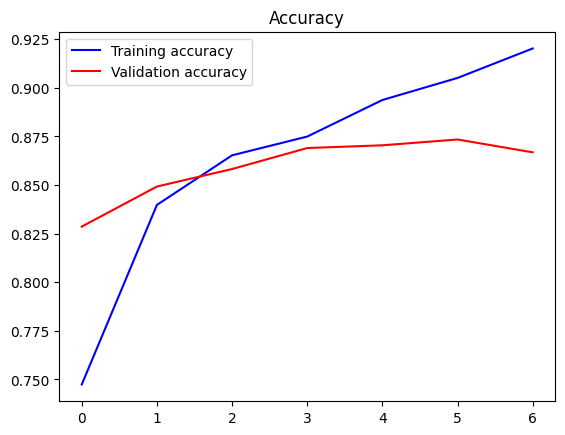

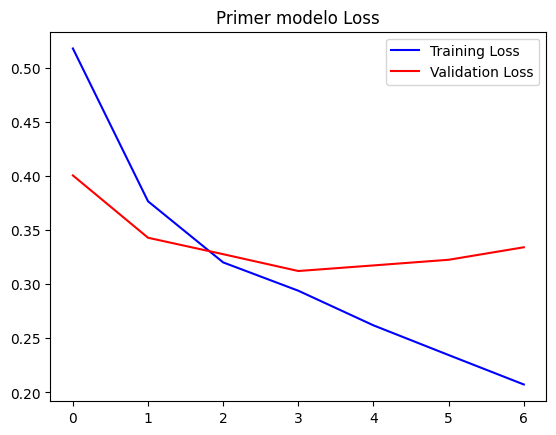

In [ ]:
PlotPerformance(history.history['accuracy'],
                history.history['val_accuracy'],
                history.history['loss'],
                history.history['val_loss'],
                'Primer modelo')

## Evaluación del modelo

El modelo se evalúa con el conjunto de prueba (no visto durante el entrenamiento).

In [ ]:
acc, loss = model.evaluate(X_test_pad, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8709 - loss: 0.3120


## Ejercicio

Calcular los valores de las siguientes métricas:
* Precision
* Recall
* F1-score
* Matriz de confusión



In [ ]:
## Código de métricas aquí

In [ ]:
model.predict(mi_texto)